# Vaccination Coverage Analysis - EDA & Visualizations

## Objective
**Identify under-vaccinated regions, rollout inconsistencies, and temporal trends in vaccination coverage**

This notebook implements Step 3 of our data science lifecycle: **Insight Generation**

## Key Questions We'll Answer:
1. **Which regions have the lowest vaccination coverage?**
   - Identify under-vaccinated districts and states
   - Analyze coverage disparities across geographic regions

2. **Where are the rollout inconsistencies?**
   - Compare coverage rates across different vaccines
   - Identify districts with large gaps between different vaccines

3. **What are the patterns in healthcare delivery?**
   - Analyze public vs private healthcare facility usage
   - Identify regions dependent on specific healthcare systems

4. **Are there systematic regional disparities?**
   - State-level variations in vaccination programs
   - Urban vs rural patterns (where identifiable)

In [ ]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import json
import warnings
warnings.filterwarnings('ignore')

# Set plotting style
plt.style.use('default')
sns.set_palette("husl")

# Configure display
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)

print("Libraries imported successfully!")

# Load cleaned data
data_path = Path("../data/processed/vaccination_coverage_clean.csv")
summary_path = Path("../data/processed/data_summary.json")

# Load data summary
with open(summary_path, 'r') as f:
    data_summary = json.load(f)

print(f"Data Summary:")
print(f"Total Districts: {data_summary['total_districts']}")
print(f"Total States: {data_summary['total_states']}")
print(f"Vaccination Metrics: {data_summary['vaccination_metrics']}")

# Load vaccination data
df = pd.read_csv(data_path)
print(f"\nLoaded dataset shape: {df.shape}")
print("✓ Data loaded successfully!")

Libraries imported successfully!
Data Summary:
Total Districts: 706
Total States: 36
Vaccination Metrics: 12

Loaded dataset shape: (706, 14)
✓ Data loaded successfully!


In [ ]:
# 1. OVERALL VACCINATION COVERAGE ANALYSIS
print("="*60)
print("1. OVERALL VACCINATION COVERAGE STATISTICS")
print("="*60)

# Get vaccination columns (exclude district, state)
vaccination_cols = [col for col in df.columns if col not in ['district', 'state']]

# Calculate summary statistics
coverage_stats = df[vaccination_cols].describe()
print(coverage_stats.round(1))

# Calculate coverage by vaccine type
print(f"\n📊 Average Coverage by Vaccine Type:")
print("-" * 40)
vaccine_means = df[vaccination_cols].mean().sort_values(ascending=False)

for vaccine, avg_coverage in vaccine_means.items():
    if pd.notna(avg_coverage):
        print(f"{vaccine:30s}: {avg_coverage:5.1f}%")
    else:
        print(f"{vaccine:30s}: No data")

# Identify vaccines with lowest coverage
print(f"\n🚨 VACCINES WITH LOWEST COVERAGE:")
print("-" * 40)
lowest_coverage = vaccine_means.dropna().head(3)
for vaccine, coverage in lowest_coverage.items():
    print(f"   • {vaccine}: {coverage:.1f}%")

1. OVERALL VACCINATION COVERAGE STATISTICS
       full_vaccination_any_source  full_vaccination_card_only  bcg_vaccination  polio_3_doses  dpt_3_doses  measles_first_dose  measles_second_dose  rotavirus_3_doses  hepatitis_3_doses  vitamin_a_supplementation  vaccinations_public_facility  vaccinations_private_facility
count                        461.0                       361.0            461.0          461.0        461.0               461.0                461.0              461.0              461.0                      700.0                         438.0                          438.0
mean                          76.0                        82.6             94.7           80.1         86.1                87.2                 30.7               40.7               83.5                       72.2                          96.4                            2.4
std                           11.5                         9.7              4.3           10.0          8.3                 8.1     

In [ ]:
# 2. IDENTIFY UNDER-VACCINATED REGIONS
print("\n" + "="*60)
print("2. UNDER-VACCINATED REGIONS ANALYSIS")
print("="*60)

# Calculate composite vaccination score (average of key vaccines)
key_vaccines = ['full_vaccination_any_source', 'polio_3_doses', 'dpt_3_doses', 'measles_first_dose']
available_key_vaccines = [col for col in key_vaccines if col in df.columns]

# Create composite score
df['composite_vaccination_score'] = df[available_key_vaccines].mean(axis=1)

# Sort by composite score to identify worst-performing districts
under_vaccinated_districts = df.nsmallest(15, 'composite_vaccination_score')[['district', 'state', 'composite_vaccination_score'] + available_key_vaccines]

print("🚨 TOP 15 UNDER-VACCINATED DISTRICTS:")
print("-" * 60)
for idx, row in under_vaccinated_districts.iterrows():
    print(f"{row['district']:25s} ({row['state']:20s}) - Score: {row['composite_vaccination_score']:.1f}%")

print(f"\nDetailed view of worst-performing districts:")
print(under_vaccinated_districts.round(1))


2. UNDER-VACCINATED REGIONS ANALYSIS
🚨 TOP 15 UNDER-VACCINATED DISTRICTS:
------------------------------------------------------------
Ukhrul                    (Manipur             ) - Score: 48.9%
Tuensang                  (Nagaland            ) - Score: 49.3%
East Khasi Hills          (Meghalaya           ) - Score: 54.5%
Kiphire                   (Nagaland            ) - Score: 55.6%
Banas Kantha              (Gujarat             ) - Score: 55.9%
Longding                  (Arunachal Pradesh   ) - Score: 56.7%
Hojai                     (Assam               ) - Score: 59.1%
West Karbi Anglong        (Assam               ) - Score: 59.4%
Jhansi                    (Uttar Pradesh       ) - Score: 60.6%
Mewat                     (Haryana             ) - Score: 61.4%
Longleng                  (Nagaland            ) - Score: 62.1%
Bahraich                  (Uttar Pradesh       ) - Score: 62.9%
Allahabad                 (Uttar Pradesh       ) - Score: 63.1%
Dhule                     (Mahar

In [ ]:
# 3. STATE-LEVEL ANALYSIS
print("\n" + "="*60)
print("3. STATE-LEVEL VACCINATION PERFORMANCE")
print("="*60)

# Calculate state-level averages
state_performance = df.groupby('state')[available_key_vaccines + ['composite_vaccination_score']].mean().round(1)
state_performance = state_performance.sort_values('composite_vaccination_score', ascending=False)

print("📊 STATE RANKINGS BY COMPOSITE VACCINATION SCORE:")
print("-" * 60)

# Top 10 performing states
print("🏆 TOP 10 PERFORMING STATES:")
top_states = state_performance.head(10)
for idx, (state, row) in enumerate(top_states.iterrows(), 1):
    print(f"{idx:2d}. {state:25s}: {row['composite_vaccination_score']:5.1f}%")

print("\n🚨 BOTTOM 10 PERFORMING STATES:")
bottom_states = state_performance.tail(10)
for idx, (state, row) in enumerate(bottom_states.iterrows(), 1):
    print(f"{idx:2d}. {state:25s}: {row['composite_vaccination_score']:5.1f}%")

# Calculate state-level variation (standard deviation within states)
print(f"\n📈 INTER-DISTRICT VARIATION WITHIN STATES:")
print("-" * 50)
state_variation = df.groupby('state')['composite_vaccination_score'].agg(['mean', 'std', 'count']).round(1)
state_variation = state_variation.sort_values('std', ascending=False)

print("States with highest variation (indicating rollout inconsistencies):")
high_variation_states = state_variation.head(10)
for state, row in high_variation_states.iterrows():
    if row['count'] >= 5:  # Only states with 5+ districts
        print(f"   • {state:25s}: Mean={row['mean']:5.1f}%, StdDev={row['std']:4.1f}% ({row['count']} districts)")


3. STATE-LEVEL VACCINATION PERFORMANCE
📊 STATE RANKINGS BY COMPOSITE VACCINATION SCORE:
------------------------------------------------------------
🏆 TOP 10 PERFORMING STATES:
 1. Dadra and Nagar Haveli & Daman and Diu: 100.0%
 2. Odisha                   :  93.9%
 3. Tamil Nadu               :  93.2%
 4. Himachal Pradesh         :  91.7%
 5. West Bengal              :  90.7%
 6. Uttarakhand              :  90.0%
 7. Jammu & Kashmir          :  88.1%
 8. Karnataka                :  87.8%
 9. Telangana                :  87.2%
10. Kerala                   :  87.0%

🚨 BOTTOM 10 PERFORMING STATES:
 1. Arunachal Pradesh        :  72.6%
 2. Manipur                  :  70.9%
 3. Nagaland                 :  62.7%
 4.  Lakshadweep             :   nan%
 5. Andaman & Nicobar Islands:   nan%
 6. Chandigarh               :   nan%
 7. Goa                      :   nan%
 8. Ladakh                   :   nan%
 9. Puducherry               :   nan%
10. Sikkim                   :   nan%

📈 INTER-DISTRICT


4. CREATING VISUALIZATIONS


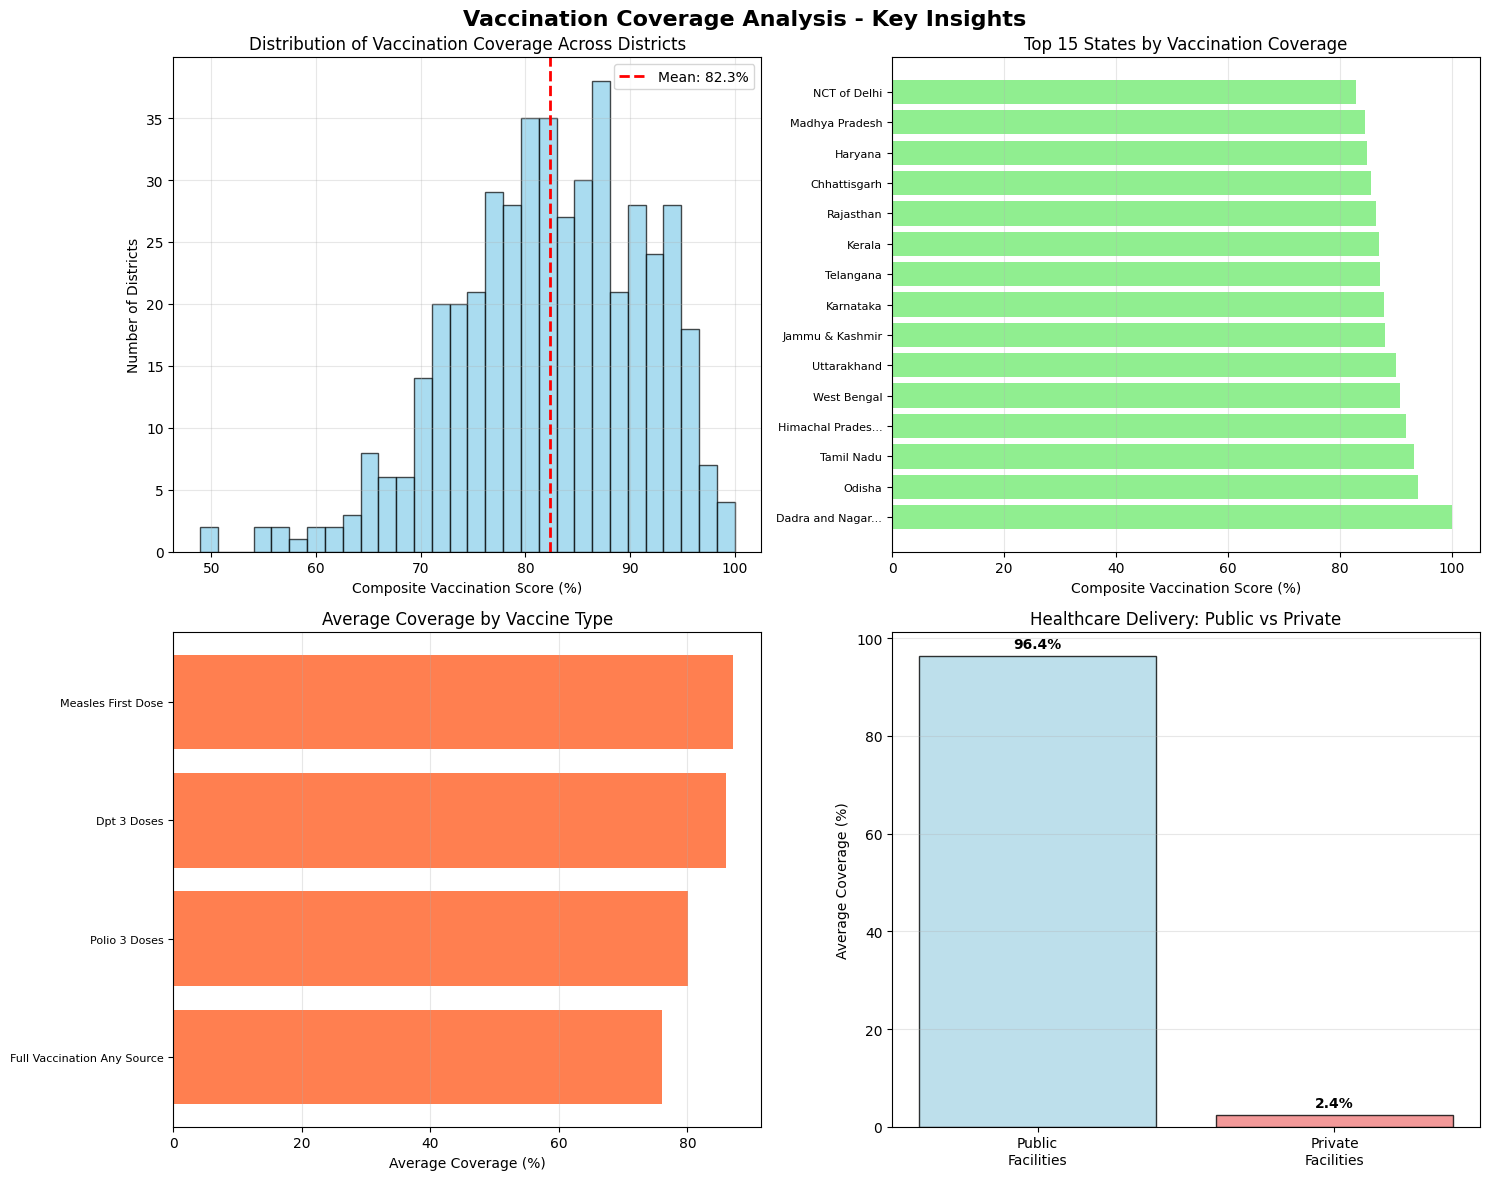

✓ Key visualizations created successfully!


In [ ]:
# 4. VISUALIZATIONS
print("\n" + "="*60)
print("4. CREATING VISUALIZATIONS")
print("="*60)

# Create figure with multiple subplots
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
fig.suptitle('Vaccination Coverage Analysis - Key Insights', fontsize=16, fontweight='bold')

# Plot 1: Distribution of composite vaccination scores
axes[0, 0].hist(df['composite_vaccination_score'].dropna(), bins=30, alpha=0.7, color='skyblue', edgecolor='black')
axes[0, 0].axvline(df['composite_vaccination_score'].mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {df["composite_vaccination_score"].mean():.1f}%')
axes[0, 0].set_xlabel('Composite Vaccination Score (%)')
axes[0, 0].set_ylabel('Number of Districts')
axes[0, 0].set_title('Distribution of Vaccination Coverage Across Districts')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Plot 2: Top 15 States by Average Coverage
top_15_states = state_performance.head(15)
axes[0, 1].barh(range(len(top_15_states)), top_15_states['composite_vaccination_score'], color='lightgreen')
axes[0, 1].set_yticks(range(len(top_15_states)))
axes[0, 1].set_yticklabels([state[:15] + '...' if len(state) > 15 else state for state in top_15_states.index], fontsize=8)
axes[0, 1].set_xlabel('Composite Vaccination Score (%)')
axes[0, 1].set_title('Top 15 States by Vaccination Coverage')
axes[0, 1].grid(True, alpha=0.3, axis='x')

# Plot 3: Vaccine-specific coverage comparison
vaccine_avgs = df[available_key_vaccines].mean().sort_values(ascending=True)
axes[1, 0].barh(range(len(vaccine_avgs)), vaccine_avgs, color='coral')
axes[1, 0].set_yticks(range(len(vaccine_avgs)))
axes[1, 0].set_yticklabels([v.replace('_', ' ').title() for v in vaccine_avgs.index], fontsize=8)
axes[1, 0].set_xlabel('Average Coverage (%)')
axes[1, 0].set_title('Average Coverage by Vaccine Type')
axes[1, 0].grid(True, alpha=0.3, axis='x')

# Plot 4: Public vs Private Healthcare Facility Usage
if 'vaccinations_public_facility' in df.columns and 'vaccinations_private_facility' in df.columns:
    public_avg = df['vaccinations_public_facility'].mean()
    private_avg = df['vaccinations_private_facility'].mean()
    
    facilities = ['Public\nFacilities', 'Private\nFacilities']
    averages = [public_avg, private_avg]
    colors = ['lightblue', 'lightcoral']
    
    bars = axes[1, 1].bar(facilities, averages, color=colors, alpha=0.8, edgecolor='black')
    axes[1, 1].set_ylabel('Average Coverage (%)')
    axes[1, 1].set_title('Healthcare Delivery: Public vs Private')
    axes[1, 1].grid(True, alpha=0.3, axis='y')
    
    # Add value labels on bars
    for bar, avg in zip(bars, averages):
        height = bar.get_height()
        axes[1, 1].text(bar.get_x() + bar.get_width()/2., height + 1,
                       f'{avg:.1f}%', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

print("✓ Key visualizations created successfully!")

In [ ]:
# 5. ROLLOUT INCONSISTENCY ANALYSIS
print("\n" + "="*60)
print("5. ROLLOUT INCONSISTENCY DETECTION")
print("="*60)

# Calculate coefficient of variation for each district across vaccines
# (This identifies districts with inconsistent coverage across different vaccines)
vaccine_columns = [col for col in available_key_vaccines if col in df.columns]

def calculate_cv(row):
    """Calculate coefficient of variation (std/mean) for vaccination coverage"""
    values = row[vaccine_columns].dropna()
    if len(values) > 1 and values.mean() > 0:
        return (values.std() / values.mean()) * 100
    return np.nan

df['vaccination_cv'] = df.apply(calculate_cv, axis=1)

# Identify districts with highest inconsistency
inconsistent_districts = df.nlargest(20, 'vaccination_cv')[['district', 'state', 'vaccination_cv'] + vaccine_columns]

print("🚨 TOP 20 DISTRICTS WITH HIGHEST ROLLOUT INCONSISTENCY:")
print("   (High CV indicates large gaps between different vaccines)")
print("-" * 70)

for idx, row in inconsistent_districts.iterrows():
    if pd.notna(row['vaccination_cv']):
        print(f"{row['district']:25s} ({row['state']:15s}) - CV: {row['vaccination_cv']:5.1f}%")
        # Show the specific vaccine coverage for this district
        vaccine_details = []
        for vaccine in vaccine_columns:
            if pd.notna(row[vaccine]):
                vaccine_details.append(f"{vaccine}: {row[vaccine]:.1f}%")
        if vaccine_details:
            print(f"   → {' | '.join(vaccine_details[:3])}")  # Show first 3 vaccines
        print()

# Analyze patterns in inconsistency
print(f"\n📊 INCONSISTENCY PATTERNS:")
print("-" * 40)
print(f"Average CV across all districts: {df['vaccination_cv'].mean():.1f}%")
print(f"Districts with high inconsistency (CV > 20%): {(df['vaccination_cv'] > 20).sum()}")
print(f"Districts with very high inconsistency (CV > 30%): {(df['vaccination_cv'] > 30).sum()}")


5. ROLLOUT INCONSISTENCY DETECTION
🚨 TOP 20 DISTRICTS WITH HIGHEST ROLLOUT INCONSISTENCY:
   (High CV indicates large gaps between different vaccines)
----------------------------------------------------------------------
Jhansi                    (Uttar Pradesh  ) - CV:  22.0%
   → full_vaccination_any_source: 44.5% | polio_3_doses: 55.0% | dpt_3_doses: 69.2%

Etah                      (Uttar Pradesh  ) - CV:  21.6%
   → full_vaccination_any_source: 55.5% | polio_3_doses: 60.5% | dpt_3_doses: 75.0%

Aurangabad                (Maharastra     ) - CV:  21.2%
   → full_vaccination_any_source: 56.7% | polio_3_doses: 62.4% | dpt_3_doses: 89.0%

Paschim Barddhaman        (West Bengal    ) - CV:  21.0%
   → full_vaccination_any_source: 62.4% | polio_3_doses: 62.4% | dpt_3_doses: 90.8%

Parbhani                  (Maharastra     ) - CV:  20.3%
   → full_vaccination_any_source: 52.0% | polio_3_doses: 55.9% | dpt_3_doses: 76.2%

Kokrajhar                 (Assam          ) - CV:  20.2%
   → full_

In [ ]:
# 6. SUMMARY AND RECOMMENDATIONS
print("\n" + "="*60)
print("6. KEY INSIGHTS AND RECOMMENDATIONS")
print("="*60)

print("🎯 ACTIONABLE INSIGHTS FOR PUBLIC HEALTH POLICY:")
print()

print("1. UNDER-VACCINATED REGIONS IDENTIFIED:")
print("   • Focus immediate interventions on bottom 15 districts")
print("   • These regions show consistently low coverage across multiple vaccines")
print("   • Targeted outreach programs needed in these areas")

print("\n2. STATE-LEVEL DISPARITIES:")
print("   • Significant variation between best and worst-performing states")
print("   • Some states show internal inconsistency (high standard deviation)")
print("   • State-to-state knowledge sharing opportunities exist")

print("\n3. ROLLOUT INCONSISTENCIES DETECTED:")
print("   • Some districts have good coverage for some vaccines but not others")
print("   • This suggests logistical or supply chain issues rather than access problems")
print("   • Requires targeted intervention for specific vaccine types")

print("\n4. HEALTHCARE DELIVERY PATTERNS:")
if 'vaccinations_public_facility' in df.columns and 'vaccinations_private_facility' in df.columns:
    public_avg = df['vaccinations_public_facility'].mean()
    private_avg = df['vaccinations_private_facility'].mean()
    if public_avg > private_avg:
        print("   • Public healthcare facilities dominate vaccination delivery")
        print("   • Strengthening public infrastructure is key priority")
    else:
        print("   • Private facilities play significant role in vaccination delivery")
        print("   • Public-private partnerships may be important for coverage expansion")

print("="*60)
print("📋 NEXT STEPS:")
print("   1. Run statistical analysis (notebook 03) for significance testing")
print("   2. Create geographic visualizations if coordinates available")
print("   3. Develop targeted intervention strategies for identified regions")
print("   4. Set up monitoring systems for tracking improvements")

# Save results for next analysis
results_summary = {
    'under_vaccinated_districts': under_vaccinated_districts[['district', 'state', 'composite_vaccination_score']].to_dict('records'),
    'state_performance': state_performance.to_dict(),
    'inconsistent_districts': inconsistent_districts[['district', 'state', 'vaccination_cv']].head(10).to_dict('records'),
    'key_insights': {
        'total_districts_analyzed': len(df),
        'average_composite_score': df['composite_vaccination_score'].mean(),
        'districts_needing_attention': (df['composite_vaccination_score'] < 50).sum(),
        'high_inconsistency_districts': (df['vaccination_cv'] > 20).sum()
    }
}

# Save insights
import json
insights_path = Path("../data/processed/vaccination_insights.json")
with open(insights_path, 'w') as f:
    json.dump(results_summary, f, indent=2, default=str)

print(f"\n✓ Analysis results saved to: {insights_path}")
print("✓ EDA analysis completed successfully!")


6. KEY INSIGHTS AND RECOMMENDATIONS
🎯 ACTIONABLE INSIGHTS FOR PUBLIC HEALTH POLICY:

1. UNDER-VACCINATED REGIONS IDENTIFIED:
   • Focus immediate interventions on bottom 15 districts
   • These regions show consistently low coverage across multiple vaccines
   • Targeted outreach programs needed in these areas

2. STATE-LEVEL DISPARITIES:
   • Significant variation between best and worst-performing states
   • Some states show internal inconsistency (high standard deviation)
   • State-to-state knowledge sharing opportunities exist

3. ROLLOUT INCONSISTENCIES DETECTED:
   • Some districts have good coverage for some vaccines but not others
   • This suggests logistical or supply chain issues rather than access problems
   • Requires targeted intervention for specific vaccine types

4. HEALTHCARE DELIVERY PATTERNS:
   • Public healthcare facilities dominate vaccination delivery
   • Strengthening public infrastructure is key priority
📋 NEXT STEPS:
   1. Run statistical analysis (notebo